In [1]:
import os
import sys

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..', '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.models.efficient_mamba import EfficientNetMamba
import random

/home/nguyenlong205/miniconda3/envs/ai_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load trained model

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# DEVICE = 'cpu'
MODEL_PATH = r"../../models/checkpoints/efficient_mamba/best_model_efficient_mamba.pth"
VIDEO_PATH = r"../../data/training_dataset/test/brush_hair/brush_hair_015.mp4"

print(f'Device      :{DEVICE}')
print(f'Model path  :{MODEL_PATH}')
print(f'Video path  :{VIDEO_PATH}')

Device      :cuda
Model path  :../../models/checkpoints/efficient_mamba/best_model_efficient_mamba.pth
Video path  :../../data/training_dataset/test/brush_hair/brush_hair_015.mp4


In [4]:
# --- Initiate model and load checkpoints ---
model = EfficientNetMamba(
    num_classes=6,
    d_model = 512,
    d_state=16,
    num_layers=2,
    d_conv=4,
    expand=2,
    dropout=0.2
    
).to(DEVICE)
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
if 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
else:
    model.load_state_dict(checkpoint)

# --- Turn to evaluation mode ---
model.eval()
print("Model loaded successfully!")

Initializing EfficientNet-B0 backbone...
Model loaded successfully!


## 2. Model analysis

### 2.1. CNN module

#### 2.1.1. Tool definition

In [41]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.handle = target_layer.register_forward_hook(self.save_activation)

    def save_activation(self, module, input, output):
        self.activations = output

    def close(self):
        self.handle.remove()

    def __call__(self, x, class_idx=None):
        logits = self.model(x)
        if self.activations is None:
            raise ValueError("Chưa bắt được activation. Kiểm tra lại target_layer.")
            
        self.activations.retain_grad()
        
        self.model.zero_grad()
        if class_idx is None:
            class_idx = torch.argmax(logits)
        
        score = logits[0, class_idx]
        score.backward(retain_graph=True) 
        
        self.gradients = self.activations.grad
        
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam)
        cam_avg = torch.mean(cam, dim=0) # (1, 7, 7)
        cam_avg = cam_avg - torch.min(cam_avg)
        cam_avg = cam_avg / (torch.max(cam_avg) + 1e-8)
        
        return cam_avg.data.cpu().numpy()[0]

In [42]:
class VideoAnalyzer:
    def __init__(self, model, target_layer, device='cuda'):
        self.model = model
        self.target_layer = target_layer
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)
        self.model.eval()
        
        self.activations = None
        self.gradients = None
        self.handle = self.target_layer.register_forward_hook(self.save_activation)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def _get_gradcam_maps(self, input_tensor, class_idx=None):
        """Tính Grad-CAM cho TẤT CẢ các frames trong tensor"""
        # Đăng ký hook cho gradient (vì cần tính từng frame)
        self.activations = None
        self.gradients = None
        
        # Forward pass
        logits = self.model(input_tensor)
        
        # Bắt activation và giữ gradient
        self.activations.retain_grad()
        
        if class_idx is None:
            class_idx = torch.argmax(logits)
        
        self.model.zero_grad()
        score = logits[0, class_idx]
        score.backward(retain_graph=True)
        
        # Lấy gradient
        grads = self.activations.grad # Shape: (Batch*T, C, H, W)
        acts = self.activations      # Shape: (Batch*T, C, H, W)
        
        # Tính trọng số và heatmap từng frame
        weights = torch.mean(grads, dim=[2, 3], keepdim=True)
        cam = torch.sum(weights * acts, dim=1, keepdim=True)
        cam = torch.nn.functional.relu(cam) # Chỉ lấy vùng tích cực
        
        return cam.detach().cpu().numpy()

    def _denormalize(self, img_tensor):
        """Chuyển tensor về ảnh RGB để hiển thị"""
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        
        # SỬA DÒNG NÀY: Thêm .detach()
        img = img_tensor.detach().permute(1, 2, 0).cpu().numpy()
        
        img = (img * std + mean)
        return np.clip(img, 0, 1)

    def analyze(self, video_path, num_random_frames=4):
        # 1. Đọc video và lấy toàn bộ frames
        cap = cv2.VideoCapture(video_path)
        all_frames = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            all_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        cap.release()

        # 2. Chọn ngẫu nhiên index
        indices = sorted(random.sample(range(len(all_frames)), num_random_frames))
        
        # 3. Chuẩn bị tensor đầu vào cho model (giả sử model nhận 16 frames)
        # Để đơn giản, ta lặp lại các frame hoặc pad nếu video ngắn
        # Ở đây tôi lấy đúng num_random_frames để demo
        processed_list = []
        for idx in indices:
            img = cv2.resize(all_frames[idx], (224, 224))
            img = img.astype(np.float32) / 255.0
            img = (img - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
            processed_list.append(img)
        
        # Shape: (1, T, 3, 224, 224)
        input_tensor = torch.tensor(np.array(processed_list)).permute(0, 3, 1, 2).unsqueeze(0).to(self.device).float()
        input_tensor.requires_grad = True

        # 4. Chạy Grad-CAM
        cam_maps = self._get_gradcam_maps(input_tensor) # Shape: (T, 1, 7, 7)

        # 5. Vẽ đồ thị 2 hàng 4 cột
        fig, axes = plt.subplots(2, num_random_frames, figsize=(16, 8))
        
        for i in range(num_random_frames):
            # Hàng 1: Ảnh Real
            real_img = self._denormalize(input_tensor[0, i])
            axes[0, i].imshow(real_img)
            axes[0, i].set_title(f"Frame {indices[i]}")
            axes[0, i].axis('off')

            # Hàng 2: Ảnh "Mắt nhìn" (Heatmap overlay)
            heatmap = cam_maps[i, 0]
            # PHÓNG TO HEATMAP lên 224x224 để chi tiết
            heatmap_resized = cv2.resize(heatmap, (224, 224))
            
            # Chuẩn hóa heatmap để vẽ màu
            heatmap_resized = (heatmap_resized - heatmap_resized.min()) / (heatmap_resized.max() - heatmap_resized.min() + 1e-8)
            heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
            heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0
            
            # Trộn ảnh gốc với heatmap (tỉ lệ 0.5 - 0.5)
            overlay = cv2.addWeighted(real_img, 0.6, heatmap_color, 0.4, 0)
            
            axes[1, i].imshow(overlay)
            axes[1, i].set_title(f"Model Vision {i+1}")
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.show()

#### 2.1.2. Analyzing

In [43]:
target_layer = model.backbone.features[-1]
analyzer = VideoAnalyzer(model, target_layer)

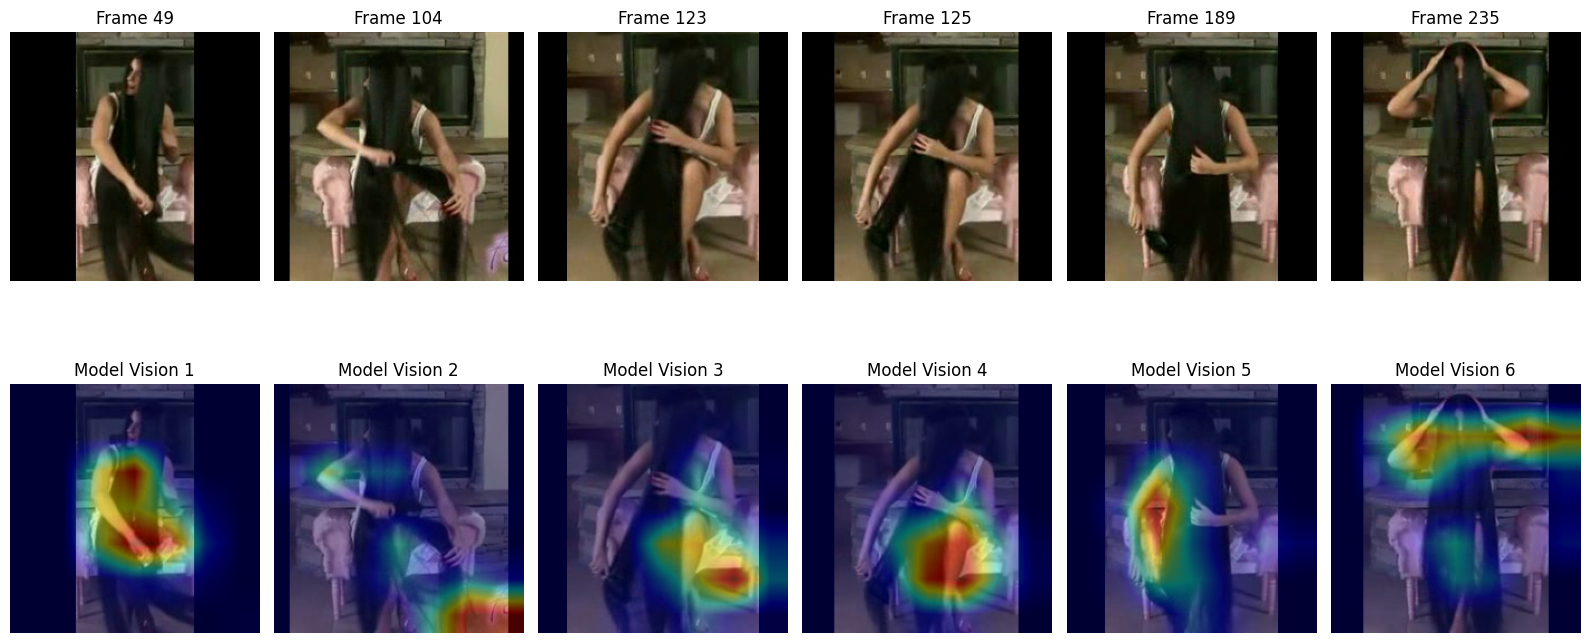

In [44]:
analyzer.analyze(VIDEO_PATH, num_random_frames=6)

### 2.2. Mamba module

#### 2.2.1. Tool definition

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
import gc

In [6]:
class MambaGrad:
    def __init__(self, model, target_layer):
        """
        Args:
            model: Mô hình EfficientNetMamba
            target_layer: Layer Mamba cần soi (thường là layer cuối của khối temporal)
        """
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        self.handle_fwd = target_layer.register_forward_hook(self.save_activation)
        self.handle_bwd = target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def close(self):
        self.handle_fwd.remove()
        self.handle_bwd.remove()

    def __call__(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        logits = self.model(input_tensor)
        
        if self.activations is None:
            raise ValueError("Chưa bắt được activation. Kiểm tra lại target_layer.")
            
        self.activations.retain_grad()
        
        if class_idx is None:
            class_idx = torch.argmax(logits)
        
        score = logits[0, class_idx]
        score.backward(retain_graph=True)
        
        grads = self.gradients
        acts = self.activations
        
        weights = torch.mean(grads, dim=1, keepdim=True)
        
        cam = torch.sum(weights * acts, dim=2)
        
        cam = F.relu(cam)
        cam = cam - torch.min(cam)
        cam = cam / (torch.max(cam) + 1e-8)

        return cam.data.cpu().numpy()[0]

In [7]:
class FrameAnalyzer:
    def __init__(self, model, target_layer, config):
        self.model = model
        self.target_layer = target_layer
        self.config = config
        self.device = next(model.parameters()).device
        self.explainer = MambaGrad(model, target_layer)

    def preprocess_video(self, video_path):
        cap = cv2.VideoCapture(str(video_path))
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()
        
        if len(frames) == 0:
            raise ValueError(f"Empty video: {video_path}")
            
        total_frames = len(frames)
        target_frames = self.config.get('num_frames', 64)
        indices = np.linspace(0, total_frames - 1, target_frames, dtype=int)
        sampled_frames = [frames[i] for i in indices]
        
        input_tensor = []
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        
        for img in sampled_frames:
            img = cv2.resize(img, (224, 224)) 
            img = img.astype(np.float32) / 255.0
            img = (img - mean) / std
            input_tensor.append(img)
            
        tensor = torch.tensor(np.array(input_tensor)).float()
        tensor = tensor.permute(0, 3, 1, 2).unsqueeze(0) 
        
        return tensor.to(self.device), sampled_frames

    def _cleanup(self):
        if hasattr(self.explainer, 'remove_hooks'):
            self.explainer.remove_hooks()
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def analyze(self, video_path, top_k=5):
        print(f"Analyzing: {video_path}")
        input_tensor = None
        try:
            input_tensor, original_frames = self.preprocess_video(video_path)
            temporal_scores = self.explainer(input_tensor)
            
            if isinstance(temporal_scores, torch.Tensor):
                temporal_scores = temporal_scores.detach().cpu().numpy().flatten()

            self._plot_rich_context(temporal_scores, original_frames, top_k)
            
        except Exception as e:
            print(f"Error: {e}")
            import traceback
            traceback.print_exc()
        finally:
            del input_tensor
            self._cleanup()

    def _plot_rich_context(self, scores, frames, top_k=5):
        high_indices = np.argsort(scores)[-top_k:]
        high_indices_sorted = sorted(high_indices)

        # Top K Low Attention
        low_indices = np.argsort(scores)[:top_k]
        low_indices_sorted = sorted(low_indices)

        fig = plt.figure(figsize=(15, 10))
        gs = fig.add_gridspec(3, top_k, height_ratios=[1.5, 1, 1]) 
        
        # === SCORE FIGURE ===
        ax_chart = fig.add_subplot(gs[0, :])
        ax_chart.plot(scores, color='#333333', linewidth=1.5, label='Attention Score')
        ax_chart.fill_between(range(len(scores)), scores, color='#333333', alpha=0.05)
        
        ax_chart.scatter(high_indices, scores[high_indices], color='green', s=30, label='High Focus', zorder=5)
        ax_chart.scatter(low_indices, scores[low_indices], color='gray', s=30, label='Low Focus', zorder=5)
        
        ax_chart.set_title("Temporal Attention Distribution", fontsize=12, fontweight='bold')
        ax_chart.set_ylabel("Score")
        ax_chart.margins(x=0.01)
        ax_chart.legend(loc='upper right')
        ax_chart.grid(True, linestyle=':', alpha=0.4)

        # === HIGH ATTENTION FRAMES ===
        for i, idx in enumerate(high_indices_sorted):
            ax = fig.add_subplot(gs[1, i])
            ax.imshow(frames[idx])
            ax.set_title(f"High #{idx}\n{scores[idx]:.3f}", fontsize=9, color='green')
            ax.axis('off')

            if i == 0:
                ax.text(-0.1, 0.5, "HIGH\nFOCUS", transform=ax.transAxes, 
                        va='center', ha='right', fontsize=10, fontweight='bold', rotation=90)

        # === LOW ATTENTION FRAMES===
        for i, idx in enumerate(low_indices_sorted):
            ax = fig.add_subplot(gs[2, i])
            ax.imshow(frames[idx])
            ax.set_title(f"Low #{idx}\n{scores[idx]:.3f}", fontsize=9, color='gray')
            ax.axis('off')
            if i == 0:
                ax.text(-0.1, 0.5, "LOW\nFOCUS", transform=ax.transAxes, 
                        va='center', ha='right', fontsize=10, fontweight='bold', rotation=90)

        plt.tight_layout()
        plt.show()

#### 2.2.2. Analysis

In [8]:
target_layer_mamba = model.layers[-1] 
frame_analyzer = FrameAnalyzer(
    model=model, 
    target_layer=target_layer_mamba,
    config={'num_frames': 64}
)

⏱️ Analyzing: ../../data/training_dataset/test/brush_hair/brush_hair_015.mp4


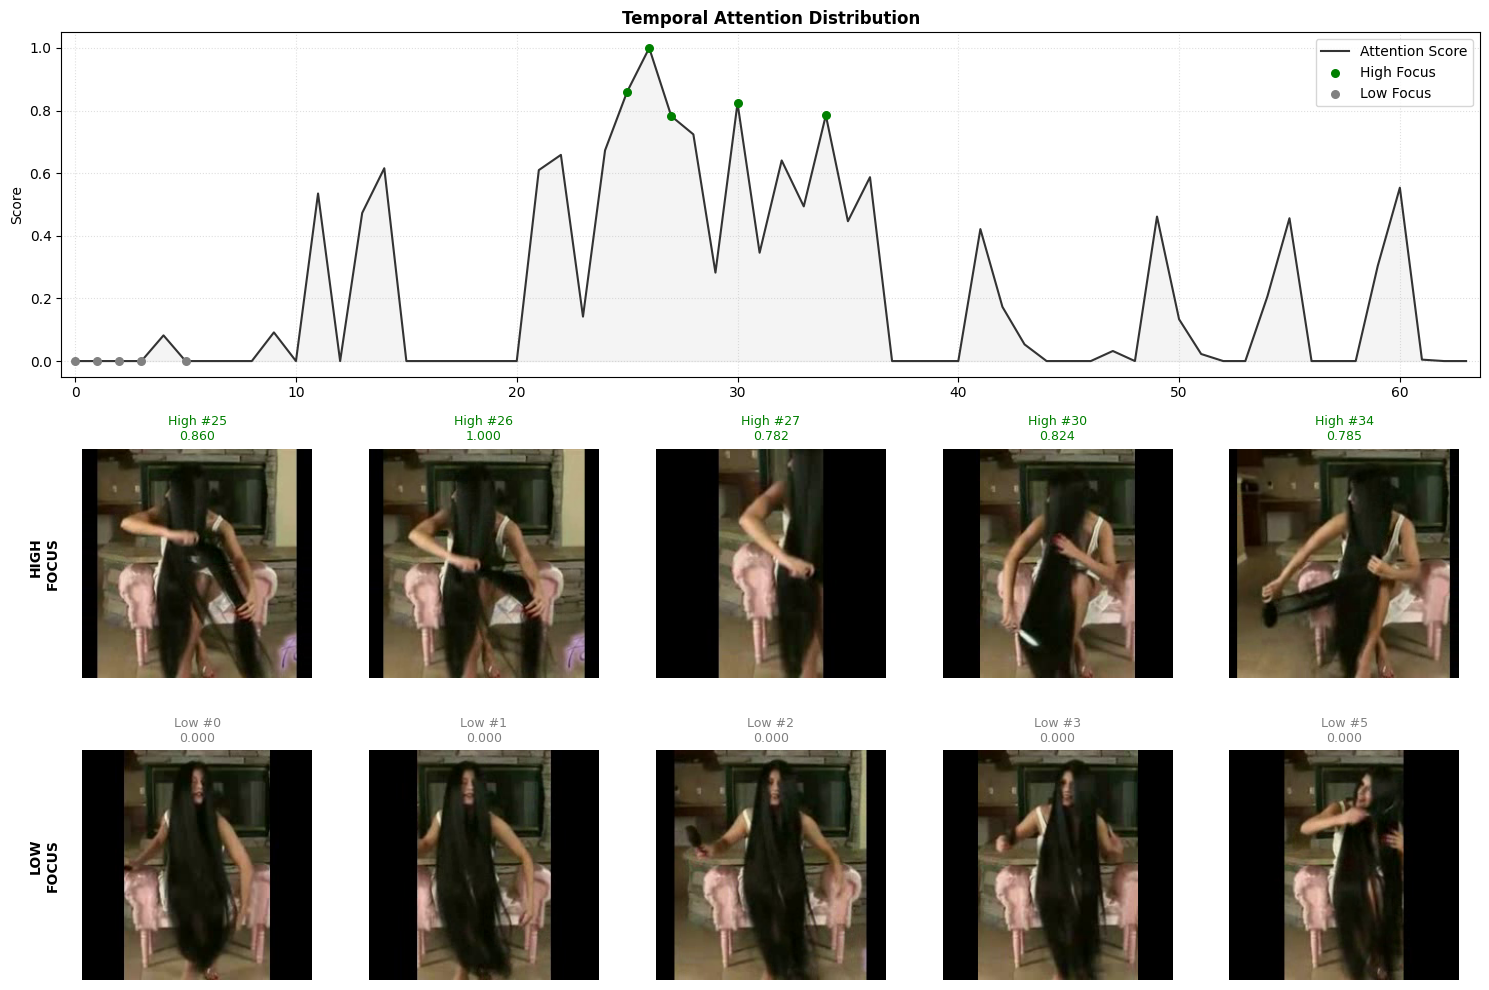

In [9]:
frame_analyzer.analyze(VIDEO_PATH)

Analyzing: ../../data/training_dataset/test/fall_floor/fall_floor_004.mp4


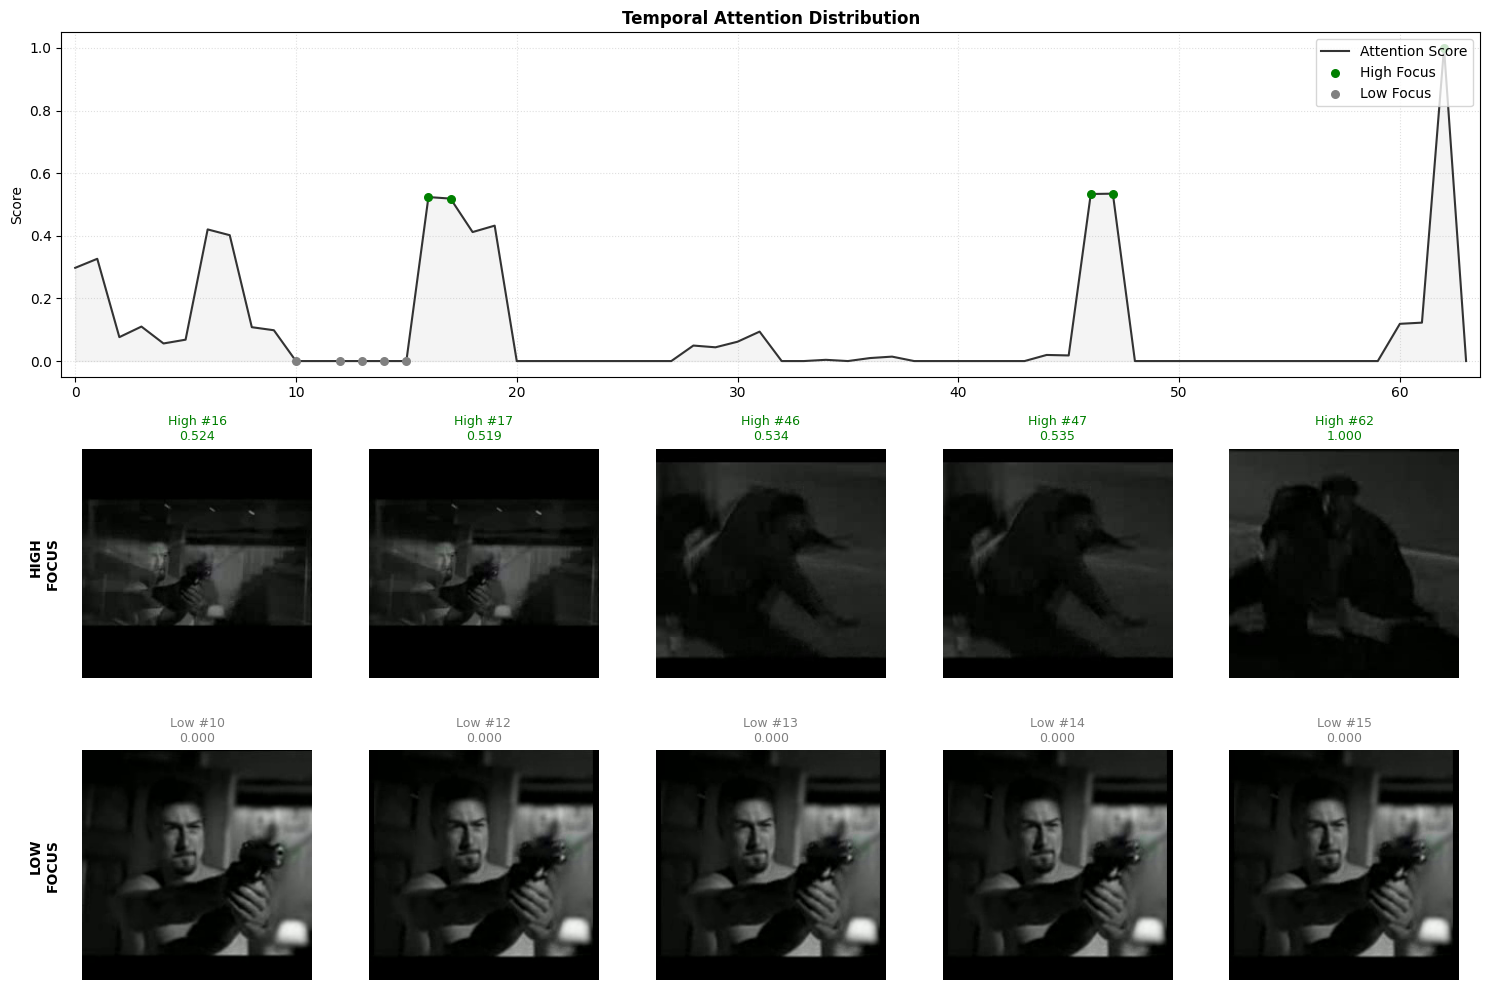

In [9]:
path_2 = r'../../data/training_dataset/test/fall_floor/fall_floor_004.mp4'
frame_analyzer.analyze(path_2)